# Student Identification & Submission Details

Please complete the following information before submitting your notebook.

**UNI:**  lmv2141

**Full Name:**  Lindsay Varzarevsky

**Public GitHub Repository URL (Final Project Report & Code):** https://github.com/lindsayvarzz/AML_Project_1

---

## Submission Requirements

- The GitHub repository **must be public**.
- The repository should include:
  - A complete and well-formatted final report
  - Clean, well-documented source code
  - Clear instructions for reproducing results (if applicable)
- Verify that all links are functional and accessible prior to submission.

# Project Submission Guidelines

### Submission Due Date: March 9, 2026

Throughout this notebook, you will encounter the keyword **`TODO`** in multiple sections. Each `TODO` indicates a required component that must be completed by you.

These may include:

- Implementing missing code
- Specifying or tuning model parameters
- Writing explanations and technical reasoning
- Performing analysis and interpreting results
- Justifying modeling decisions
- Completing evaluation procedures

---

## Expectations

You are expected to:

- Replace **every** `TODO` with correct, fully functional code.
- Provide complete, clear, and technically sound explanations where required.
- Justify modeling choices using appropriate reasoning and evidence.
- Ensure the notebook executes from start to finish **without errors**.

> **Note:** Any section that still contains `TODO` at the time of submission will be considered **incomplete**.

# World Happiness Classification Competition

## Project Objectives

This competition is designed to help you:

- Develop a deep understanding of how machine learning models function
- Understand the role and impact of model hyperparameters
- Learn from systematic experimentation and model iteration
- Produce a professional, well-structured notebook report
- Publish the final project as a portfolio-ready GitHub repository

---

## Project Workflow

You will complete the project through the following stages:

1. **Load and Merge Datasets**  
   - Import all relevant datasets  
   - Perform necessary joins and validation  

2. **Data Preprocessing**  
   - Build preprocessing pipelines using `sklearn`'s `ColumnTransformer`  
   - Handle missing values, encoding, scaling, and feature engineering  

3. **Model Training**  
   - Fit the model using the processed data  
   - Save both the preprocessing pipeline and trained model  

4. **Prediction and Evaluation**  
   - Generate predictions  
   - Evaluate performance using appropriate metrics  

5. **Hyperparameter Tuning**  
   - Systematically tune model parameters  
   - Compare performance across configurations  

6. **Deep Learning Experimentation**  
   - Implement and evaluate a neural network approach  
   - Compare results with classical ML models  

7. **Model Explainability (SHAP)**  
   - Apply SHAP for feature importance analysis  
   - Interpret and explain model decisions  

8. **Final Report Submission**  
   - Clean and organize the notebook  
   - Ensure full reproducibility  
   - Upload the final report and code to a public GitHub repository  

---

## 0. Loading Datasets

In this section, we load the **World Happiness 2023** datasets that will be used throughout the project.

**Objectives of this stage:**

- Import the datasets into the notebook environment
- Inspect their structure and contents
- Verify column names and data types
- Identify potential inconsistencies before merging

> Careful dataset inspection at this stage prevents downstream errors and ensures a clean modeling pipeline.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

#Load the dataset
whr_df = pd.read_csv('data/WHR_2023.csv')

#Inspect the first few rows to understand the structure
whr_df

,country,region,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
0,Finland,Western Europe,7.804,1.888,1.585,0.535,0.772,0.126,0.535
1,Denmark,Western Europe,7.586,1.949,1.548,0.537,0.734,0.208,0.525
2,Iceland,Western Europe,7.530,1.926,1.620,0.559,0.738,0.250,0.187
3,Israel,Middle East and North Africa,7.473,1.833,1.521,0.577,0.569,0.124,0.158
4,Netherlands,Western Europe,7.403,1.942,1.488,0.545,0.672,0.251,0.394
...,...,...,...,...,...,...,...,...,...
132,Congo (Kinshasa),Sub-Saharan Africa,3.207,0.531,0.784,0.105,0.375,0.183,0.068
133,Zimbabwe,Sub-Saharan Africa,3.204,0.758,0.881,0.069,0.363,0.112,0.117
134,Sierra Leone,Sub-Saharan Africa,3.138,0.670,0.540,0.092,0.371,0.193,0.051
135,Lebanon,Middle East and North Africa,2.392,1.417,0.476,0.398,0.123,0.061,0.027


In [3]:
# Convert the regression target ('happiness_score') into classification labels
# We'll use quartiles to create 4 happiness categories: Very Low, Low, High, Very High

# Define quartiles
whr_df['happiness_category'] = pd.qcut(whr_df['happiness_score'],
                                       q=5,
                                       labels=['Very Low', 'Low','Average', 'High', 'Very High'])

# Select features and target
X = whr_df.drop(columns=['happiness_score', 'happiness_category'])
y = whr_df['happiness_category']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Convert y_train and y_test to numerical labels
y_train_labels = y_train.astype('category').cat.codes

#TODO (Completed): Complete in a similar manner as above
y_test_labels = y_test.astype('category').cat.codes

### Conceptual Question

In the next cell, briefly explain the following:

1. What does `y_train.astype('category').cat.codes` do?
2. What is the difference between `y_train_labels` and `y_train`?

Keep your explanation clear and concise.

Response:

1. y_train.astype('category').cat.codes turns the target variable's labeled string categories that we defined earlier (ex: "very low","low","average","high","very high", etc) into numerically coded categories so that a machine can interpret it where, for example, 0 can mean very low, 1 = low, 2 = average, 3 = high, 4 = very high.

2. The difference between y_train_labels and y_train is that y_train_labels are the same categories, but just numerically encoded for machine learning readibility. It is best practice to keep the y_train dataset as strings for interpretability, but use the y_train_labels dataset to use for model training.

### Add New Data

In [4]:
#Truncated and cleaned up region data to merge
countrydata = pd.read_csv("data/newcountryvars.csv")

countrydata.head()

,country_name,population,population_below_poverty_line,hdi,life_expectancy,expected_years_of_schooling,mean_years_of_schooling,gni
0,India,1339180127,21.9,0.623559,68.322,11.696590,6.298834,5663.474799
1,Nigeria,190886311,70.0,0.527105,53.057,9.970482,6.000000,5442.901264
2,Mexico,129163276,46.2,0.761683,76.972,13.299090,8.554985,16383.106680
3,Pakistan,197015955,29.5,0.550354,66.365,8.106910,5.089460,5031.173074
4,Bangladesh,164669751,31.5,0.578824,71.985,10.178706,5.241577,3341.490722


In [5]:
# Merge in new data to X_train and X_test by taking "country" from first table and "country_name" from 2nd table.
# Also check which countries are common in both the datasets, and which type of merge will you perform for the best results.
# Hint: Look on the 'how' parameter of megre function of pandas.

#to make a complete modeling-ready dataset, it looks like there's some cleaning left to do, I should ensure that we are merging all same countries where applicable. *confirmed this at TA Office Hours*
# There are are a lot of countries that will not be able to merge because they have different punctuation/naming conventions in the different datasets. 

# So first, I'm going to identify the countries across the two datasets with these issues, standardize/normalize, manually define country mappings, and then merge them. This will be beneficial to having as complete a dataset as possible. 

#  code to check which countries are different between the datasets:

import re

def normalize_country_name(name):
    if pd.isna(name):
        return name
    name = str(name).strip().lower()
    name = re.sub(r"[^\w\s()\-&,]", "", name)
    name = re.sub(r"\s+", " ", name)
    return name

country_map = {
    "hong kong sar of china": "hong kong",
    "hong kong special administrative region": "hong kong",
    "turkiye": "turkey",
    "republic of turkiye": "turkey",
    "czechia": "czech republic",
    "viet nam": "vietnam",
    "taiwan province of china": "taiwan",
    "china, taiwan province of china": "taiwan",
    "taiwan, china": "taiwan",
    "state of palestine": "palestine",
    "congo (brazzaville)": "republic of the congo",
    "congo, republic of": "republic of the congo",
    "republic congo": "republic of the congo",
    "congo (kinshasa)": "democratic republic of the congo",
    "democraticrepublic of congo": "democratic republic of the congo",
    "democratic republic of congo": "democratic republic of the congo",
    "congo, democratic republic of the": "democratic republic of the congo",
    "drc": "democratic republic of the congo",
    "macedonia": "north macedonia",
    "former yugoslav republic of macedonia": "north macedonia",
    "swaziland": "eswatini"
}

countrydata["country_clean"] = (
    countrydata["country_name"]
    .apply(normalize_country_name)
    .replace(country_map)
)


#TODO:

X_train["country_clean"] = X_train["country"].apply(normalize_country_name).replace(country_map)
X_test["country_clean"] = X_test["country"].apply(normalize_country_name).replace(country_map)

countrydata_subset = countrydata[
    [
        "country_name",
        "country_clean",
        "population",
        "population_below_poverty_line",
        "hdi",
        "life_expectancy",
        "expected_years_of_schooling",
        "mean_years_of_schooling",
        "gni"
    ]
]

X_train = pd.merge(X_train, countrydata_subset, on="country_clean", how="left")
X_test = pd.merge(X_test, countrydata_subset, on="country_clean", how="left")

X_train = X_train.drop(columns=["country_name"])
X_test = X_test.drop(columns=["country_name"])

In [6]:
X_train

,country,region,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption,country_clean,population,population_below_poverty_line,hdi,life_expectancy,expected_years_of_schooling,mean_years_of_schooling,gni
0,Madagascar,Sub-Saharan Africa,0.632,0.779,0.178,0.187,0.177,0.134,madagascar,2.557090e+07,70.7,0.512149,65.515,10.346140,6.145955,1319.699397
1,Mauritania,Sub-Saharan Africa,1.099,0.764,0.244,0.320,0.130,0.195,mauritania,4.420184e+06,31.0,0.513106,63.239,8.463790,4.266000,3527.264154
2,Mongolia,East Asia,1.379,1.494,0.244,0.425,0.239,0.058,mongolia,3.075647e+06,21.6,0.734832,69.806,14.845520,9.750000,10449.207270
3,Tajikistan,Commonwealth of Independent States,0.972,1.248,0.291,0.599,0.104,0.292,tajikistan,8.921343e+06,31.5,0.627472,69.582,11.261860,10.355820,2600.585607
4,Ukraine,Central and Eastern Europe,1.358,1.354,0.355,0.551,0.265,0.016,ukraine,4.422295e+07,24.1,0.743049,71.129,15.306720,11.340000,7361.011228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,South Korea,East Asia,1.853,1.188,0.603,0.446,0.112,0.163,south korea,5.098221e+07,12.5,0.900992,82.128,16.587520,12.179211,34540.649270
91,Ethiopia,Sub-Saharan Africa,0.793,1.114,0.250,0.451,0.283,0.101,ethiopia,1.049574e+08,29.6,0.447750,64.602,8.351520,2.580780,1522.954782
92,China,East Asia,1.510,1.249,0.468,0.666,0.115,0.145,china,1.409517e+09,3.3,0.737681,75.963,13.535750,7.641840,13345.477460
93,Peru,Latin America and Caribbean,1.390,1.153,0.499,0.549,0.073,0.027,peru,3.216548e+07,22.7,0.739749,74.814,13.386340,9.013470,11294.840330


---

## 1. Exploratory Data Analysis and Visualization (EDAV)

In [13]:
print(X_train.dtypes)

country                           object
region                            object
gdp_per_capita                   float64
social_support                   float64
healthy_life_expectancy          float64
freedom_to_make_life_choices     float64
generosity                       float64
perceptions_of_corruption        float64
country_clean                     object
population                       float64
population_below_poverty_line    float64
hdi                              float64
life_expectancy                  float64
expected_years_of_schooling      float64
mean_years_of_schooling          float64
gni                              float64
dtype: object


### Describe What You Observe

**TODO**

Some categorical variables such as country, region, and country_clean contain text values (strings), so pandas assigns them the object data type. The country_clean variable is a derived column created during preprocessing to standardize country names for merging across datasets. The remaining variables are continuous numerical variables stored as float64, which allows them to represent decimal values rather than only integers.

### Missing Values Analysis

Compute the number and percentage of missing values for each column and present the results in a clear summary table.

In [16]:
#completed TODO:

missing_count = X_train.isna().sum()

# Percentage of missing values
missing_percent = (X_train.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percent": missing_percent
})
missing_summary

,Missing Count,Missing Percent
country,0,0.00
region,0,0.00
gdp_per_capita,0,0.00
social_support,0,0.00
healthy_life_expectancy,0,0.00
freedom_to_make_life_choices,0,0.00
generosity,0,0.00
perceptions_of_corruption,0,0.00
country_clean,0,0.00
population,1,1.05


### Distribution of Key Numerical Features

Select relevant numerical features and plot their histograms. Choose features that may influence the target variable, and briefly comment on notable patterns, skewness, or outliers.

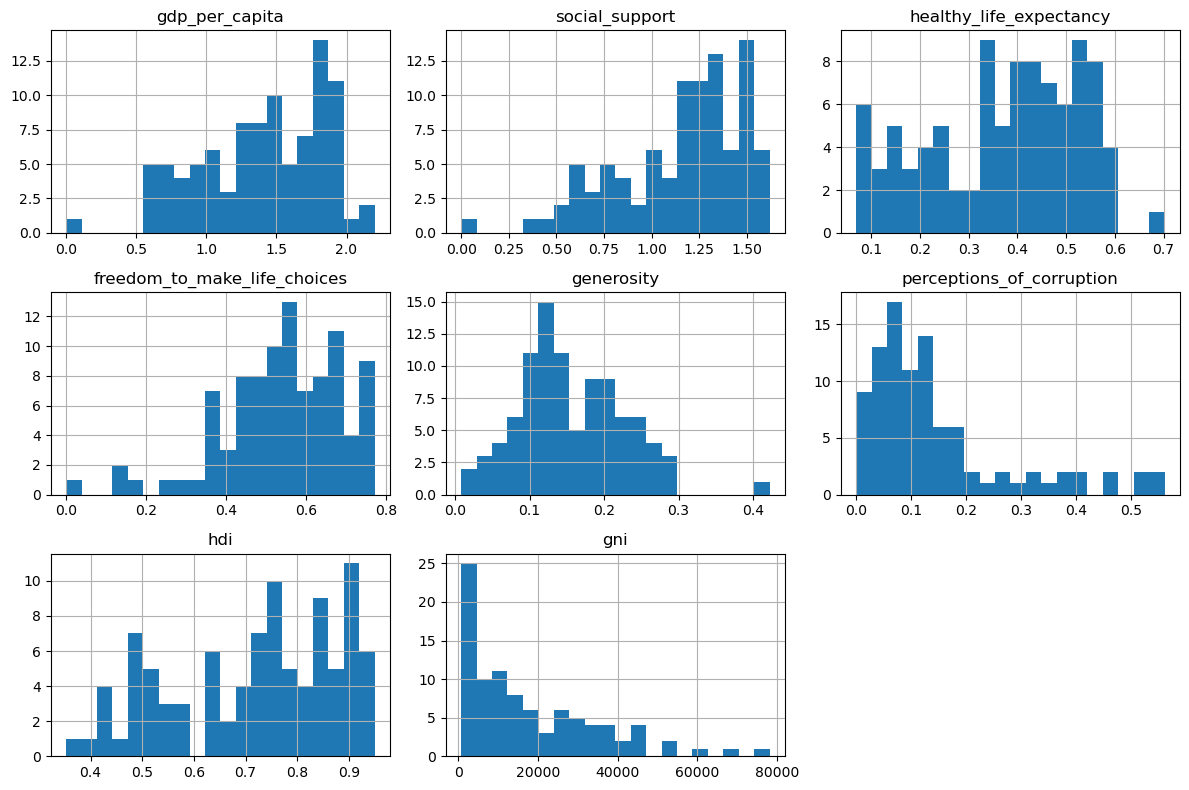

In [18]:
#Completed TODO:

numeric_features = [
    "gdp_per_capita",
    "social_support",
    "healthy_life_expectancy",
    "freedom_to_make_life_choices",
    "generosity",
    "perceptions_of_corruption",
    "hdi",
    "gni"
]

import matplotlib.pyplot as plt

X_train[numeric_features].hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

In the numerical features that I've selected here, GDP per capita and GNI appear to be right-skewed, indicating that most countries have relatively lower income levels per capita while for gni - few countries have relatively high gni coefficients. Other chosen variables suhc as social support, healthy life expectancy an freedom to make life choices appear more evenly distributed with the occasional outliers. Genorosity indicates that fewer countries have higher values, while HDI values cluster towards the higher range, indicating that within this dataset, many countries have relatively high human development scores. 

### Distribution of Categorical Variables

Plot the distribution of relevant categorical variables using appropriate visualizations (e.g., count plots or bar charts). Briefly comment on class imbalance or notable patterns.

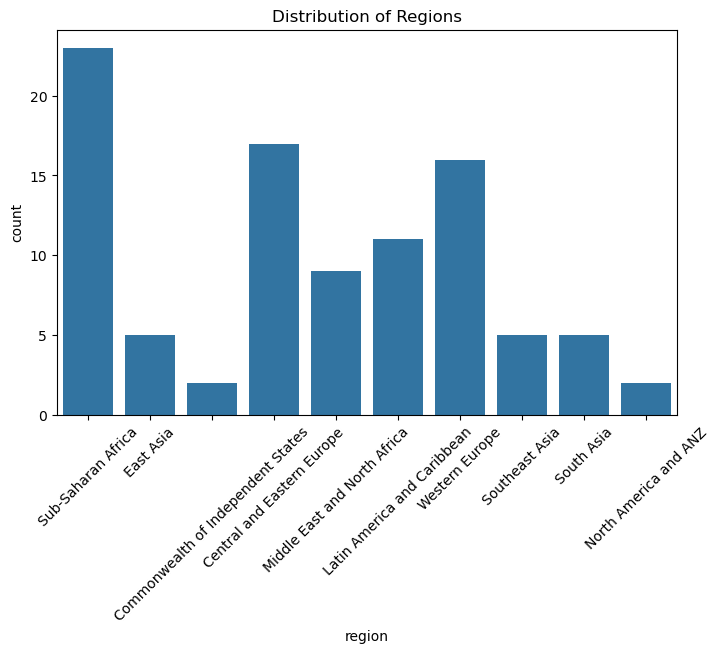

In [20]:
#Completed TODO:

import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=X_train, x="region")
plt.title("Distribution of Regions")
plt.xticks(rotation=45)
plt.show()

The regional categorical variable shows imbalanced distribution across categories. Sub-Saharan Africa contains the highest number of countries in the dataset, while regions such as North America & ANZ and the Commonwealth of Independent States have relatively few observations. Other regions such as Western Europe and Latin America & the Caribbean have moderate representation. This imbalance may influence modeling results because some regions will contribute more training data than others.

### Feature Correlation Analysis

Analyze the relationships between numerical features using correlation coefficients. Compute and visualize:

- **Pearson correlation** — linear relationships
- **Spearman correlation** — monotonic relationships
- **Kendall correlation** — rank-based relationships

Use correlation matrices and heatmaps where appropriate. Briefly interpret strong positive or negative correlations and discuss potential multicollinearity.

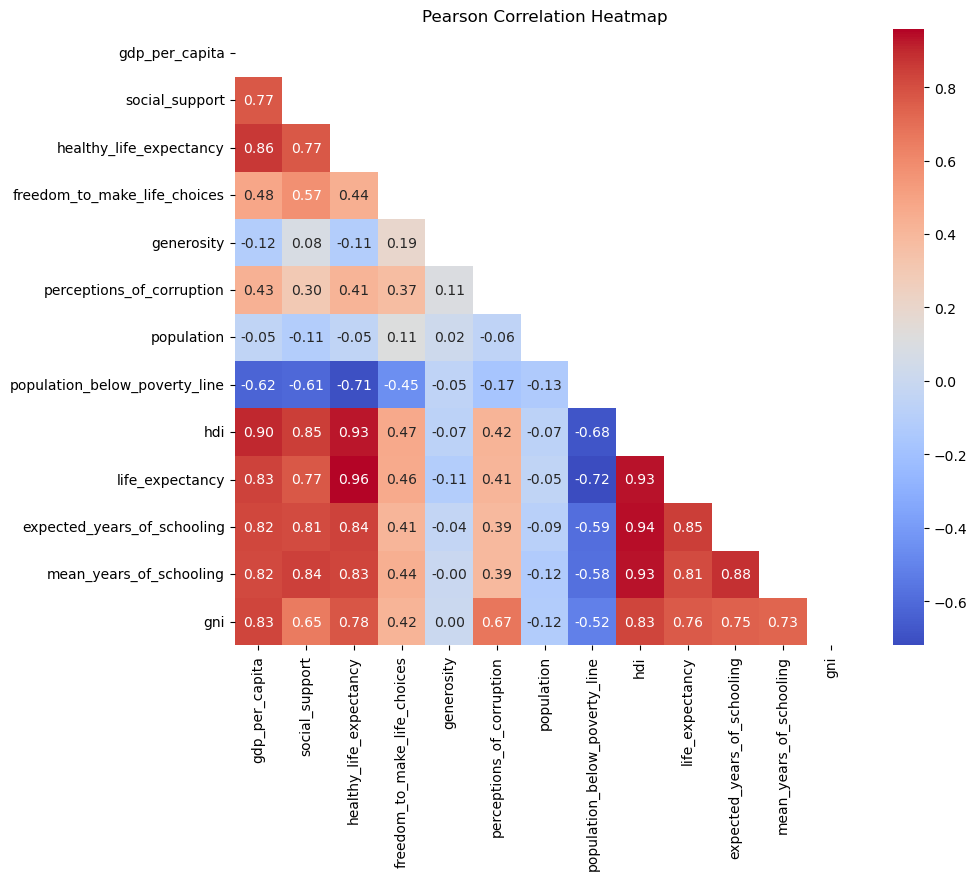

In [ ]:
#Pearson Correlation:

corr_pearson = X_train.select_dtypes(include=["float64","int64"]).corr(method="pearson")

mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

plt.figure(figsize=(10,8))
sns.heatmap(corr_pearson, mask=mask, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Pearson Correlation Heatmap")
plt.show()

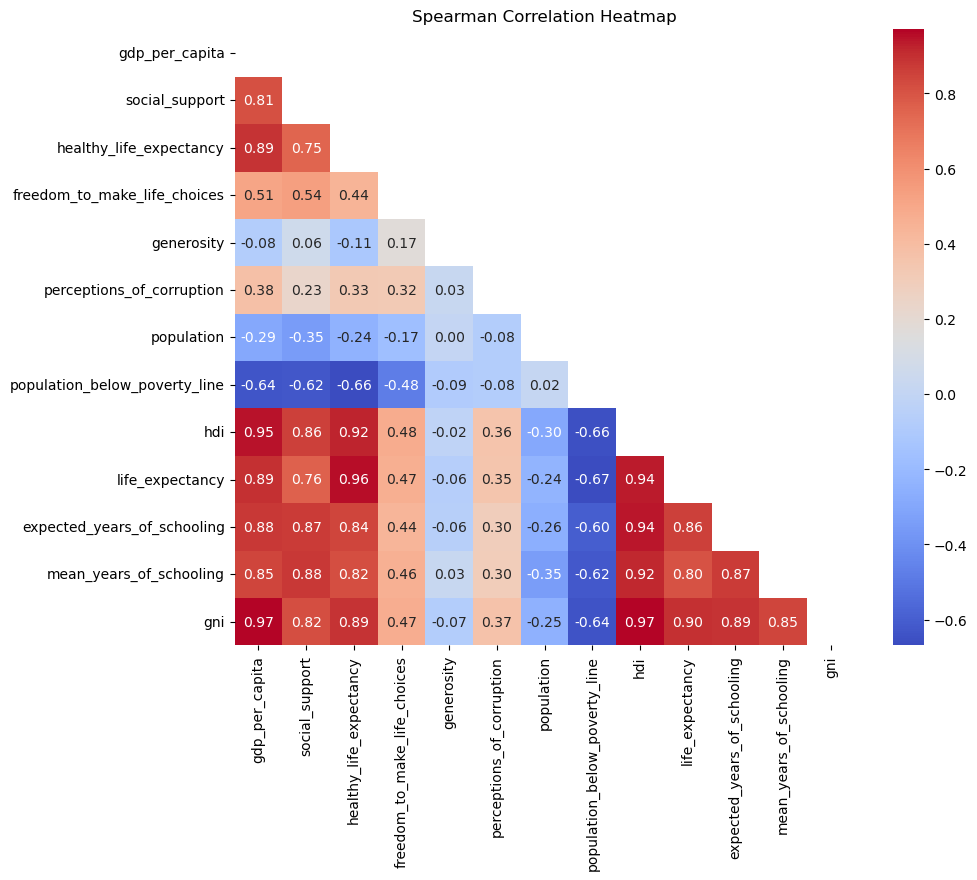

In [34]:
#Spearman Correlation:

corr_spearman = X_train.select_dtypes(include=["float64","int64"]).corr(method="spearman")

mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

plt.figure(figsize=(10,8))
sns.heatmap(corr_spearman, mask=mask, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Spearman Correlation Heatmap")
plt.show()

Interpretation:

The Pearson, Spearman, and Kendall correlation heatmaps reveal similar patterns across the numerical variables. Strong positive correlations appear among GDP per capita, GNI, HDI, life expectancy, and education variables, suggesting that economic prosperity and development indicators tend to increase together. Because the correlations remain strong across all three methods, the relationships appear both linear and monotonic. These strong associations may also indicate potential multicollinearity between several economic indicators.

### Bivariate Analysis and Relationship Exploration

Explore relationships between features and examine how they associate with the target variable. Include:

- Bivariate plots (e.g., scatter plots, box plots, grouped bar charts)
- Correlation tables
- Comparisons of feature distributions across target classes

Briefly summarize key relationships and any patterns that may influence model performance.

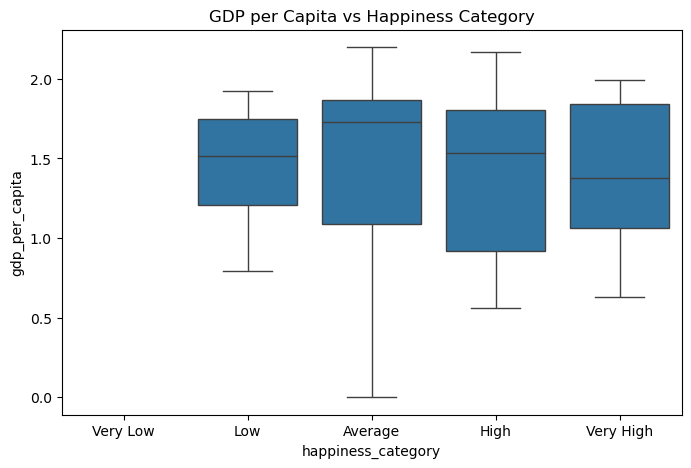

In [ ]:
#Completed TODO:

#Boxplot: Showing how a numeric feature changes across target classes.
plt.figure(figsize=(8,5))
sns.boxplot(x=y_train, y=X_train["gdp_per_capita"])
plt.title("GDP per Capita vs Happiness Category")
plt.show()


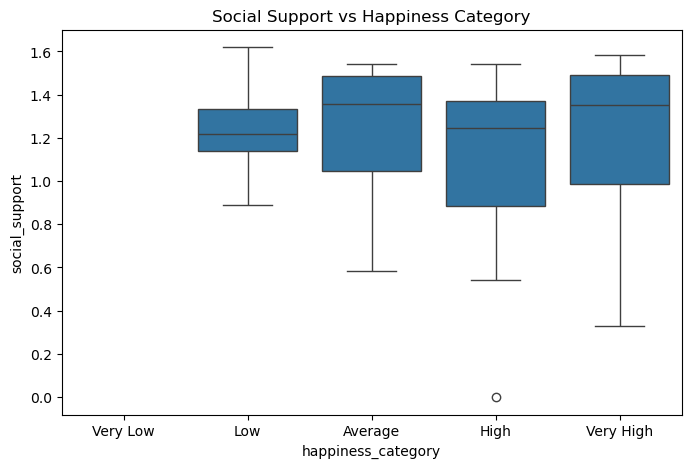

In [40]:
plt.figure(figsize=(8,5))
sns.boxplot(x=y_train, y=X_train["social_support"])
plt.title("Social Support vs Happiness Category")
plt.show()

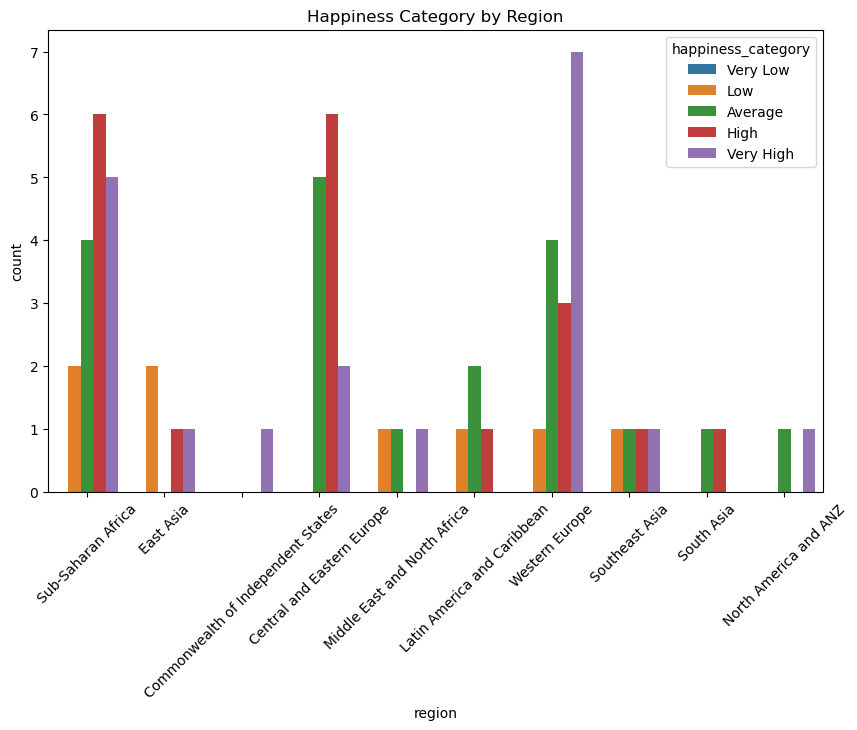

In [ ]:
#Grouped bar chart — Region vs happiness category:

#Shows target distribution across categories.

plt.figure(figsize=(10,6))
sns.countplot(x=X_train["region"], hue=y_train)
plt.xticks(rotation=45)
plt.title("Happiness Category by Region")
plt.show()

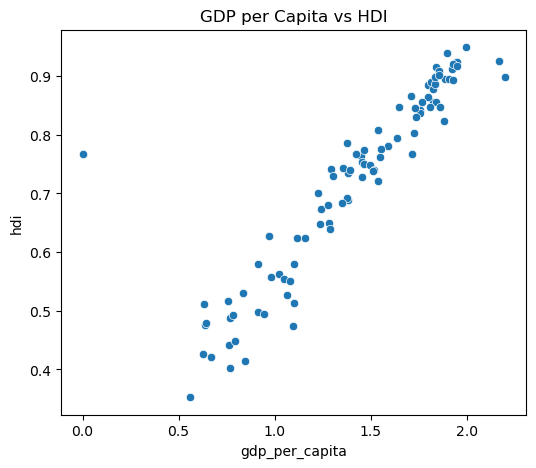

In [ ]:
#Scatter Plot: Showing relationships between predictors

plt.figure(figsize=(6,5))
sns.scatterplot(x=X_train["gdp_per_capita"], y=X_train["hdi"])
plt.title("GDP per Capita vs HDI")
plt.show()

Interpretation: The bivariate analysis reveals several relationships between predictors and the target variable. Higher happiness categories tend to be associated with higher GDP per capita and stronger social support, suggesting that economic prosperity and social networks are important predictors of well-being. The scatter plot between GDP per capita and HDI shows a strong positive relationship, indicating that countries with higher income levels also tend to have higher human development. Regional comparisons also suggest that some regions contain more countries in higher happiness categories, highlighting possible geographic patterns in well-being.

### Outlier Detection

Identify potential outliers in the numerical features using appropriate methods such as:

- Box plots
- Z-score analysis
- Interquartile Range (IQR) method

Highlight any significant anomalies and briefly comment on whether they should be retained, transformed, or removed.

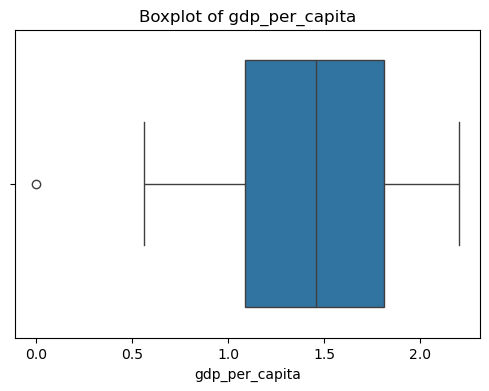

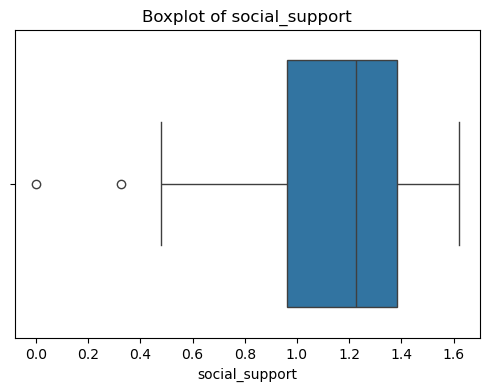

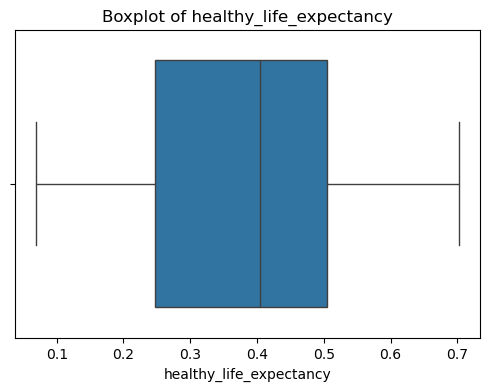

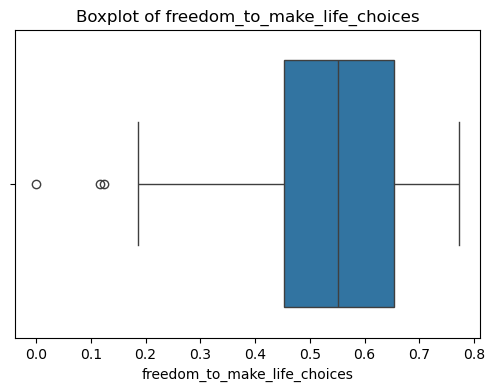

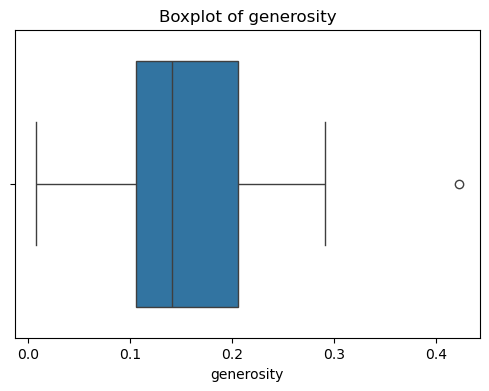

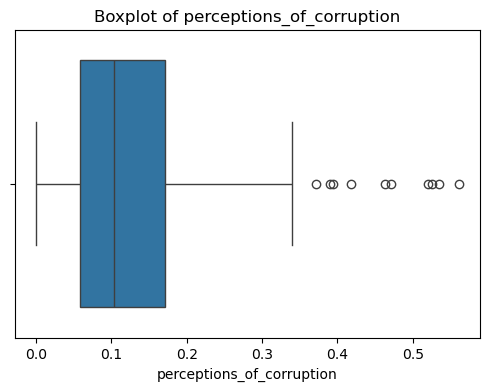

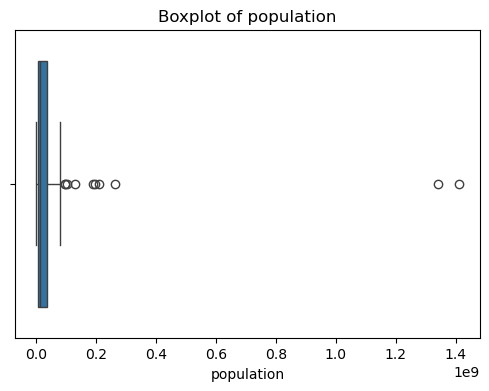

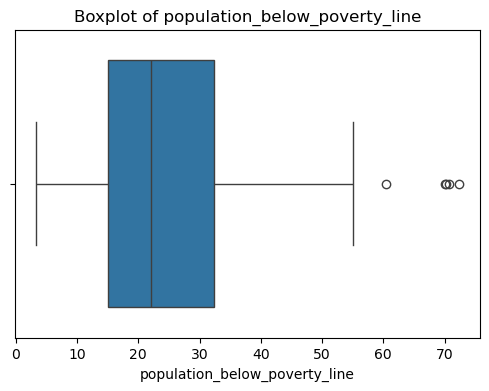

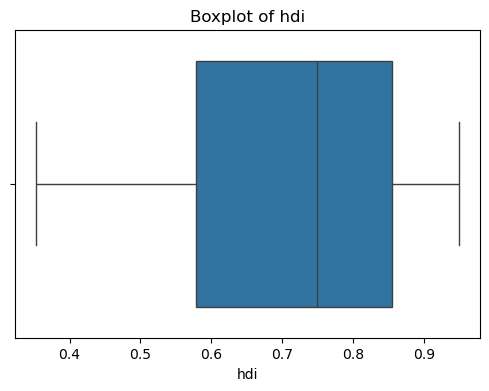

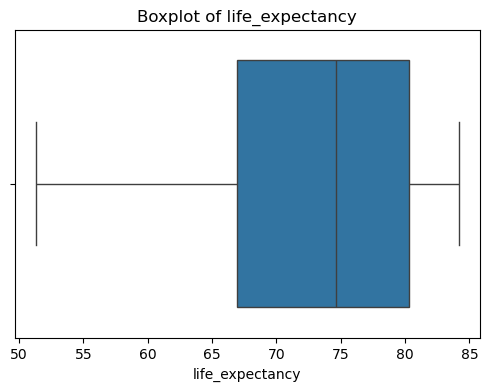

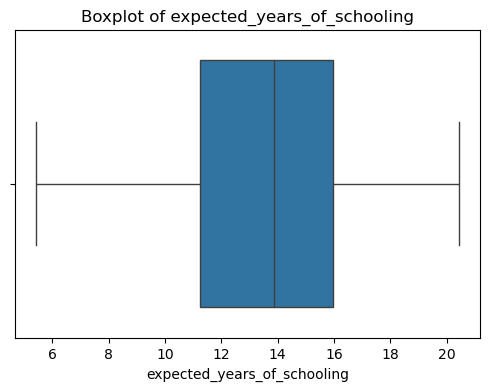

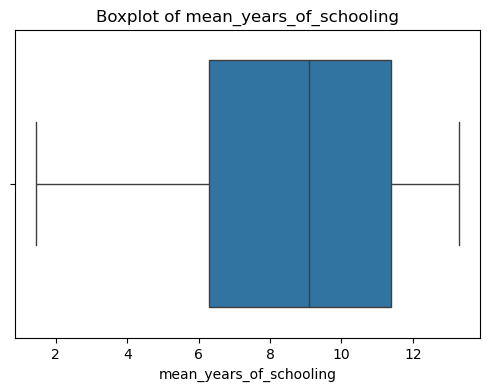

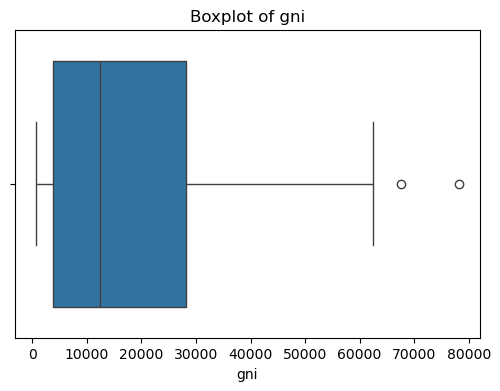

In [43]:
numerical_cols = X_train.select_dtypes(include=["float64","int64"]).columns

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=X_train[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [48]:
from scipy.stats import zscore
import numpy as np

z_scores = np.abs(zscore(X_train.select_dtypes(include=["float64","int64"])))

outliers_z = (z_scores > 3)

print("Number of Z-score outliers per feature:")
print(outliers_z.sum())

Number of Z-score outliers per feature:
5


In [46]:
numeric_cols = X_train.select_dtypes(include=["float64","int64"])

Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = ((numeric_cols < (Q1 - 1.5 * IQR)) | (numeric_cols > (Q3 + 1.5 * IQR)))

print("Number of IQR outliers per feature:")
print(outliers_iqr.sum())

Number of IQR outliers per feature:
gdp_per_capita                    1
social_support                    2
healthy_life_expectancy           0
freedom_to_make_life_choices      3
generosity                        1
perceptions_of_corruption        10
population                       10
population_below_poverty_line     5
hdi                               0
life_expectancy                   0
expected_years_of_schooling       0
mean_years_of_schooling           0
gni                               2
dtype: int64


### Observations and General Comments

Summarize your key findings from the exploratory analysis. Include:

- Important patterns or relationships identified
- Presence of missing values or outliers
- Potential feature engineering considerations
- Any preprocessing steps that should be applied before modeling

Keep your comments concise and evidence-based.

My Response:
Exploratory analysis revealed several important patterns in the dataset. Most socioeconomic indicators such as life expectancy, HDI, and education variables exhibit relatively symmetric distributions with limited outliers, suggesting stable measurement across countries. However, several economic and demographic variables show significant skewness and extreme values.

Boxplots and IQR analysis indicate that population, GDP per capita, and GNI contain notable outliers. These variables are heavily right-skewed due to structural differences between small economies and very large or wealthy countries. Because these values represent legitimate economic variation rather than data errors, they should be retained but transformed using a log transformation to reduce skewness and improve model stability.

Additional outliers were observed in perceptions of corruption and population below the poverty line, where several countries exhibit unusually high values. These values likely reflect real institutional and economic differences across countries and therefore should be retained rather than removed.

Other variables such as healthy life expectancy, HDI, life expectancy, and schooling indicators appear well distributed with minimal outliers and do not require additional preprocessing.

Prior to modeling, applying log transformations to highly skewed variables such as population, GDP per capita, and GNI may help normalize their distributions and improve model performance.

This is not a data error, however - looking at populations like China, India, the US - are orders of magnitude largers than others 

*Replace this section with your response.*

**TODO**

---
## 2. Feature Engineering

Apply log transformations to normalize skewed numerical features and improve model stability (if applicable).

#population, gni, gdp_per_cap

In [64]:
#Completed TODO:

#if creating these variables for X_test, we should also create them for X_train, to ensure that the same transformations are applied to both datasets.

X_train["log_population"] = np.log1p(X_train["population"])
X_train["log_gdp_per_capita"] = np.log1p(X_train["gdp_per_capita"])
X_train["log_gni"] = np.log1p(X_train["gni"])

X_test["log_population"] = np.log1p(X_test["population"])
X_test["log_gni"] = np.log1p(X_test["gni"])
X_test["log_gdp_per_capita"] = np.log1p(X_test["gdp_per_capita"])

Create at least one interaction feature to capture relationships between existing variables and enhance predictive power.

Explanation: **NOT DONE***
Reasoning to choose social support and life expectancy: Life expectancy may change depending on different levels of social support

In [66]:
#Completed TODO:

#if creating interaction features for X_test, we should also create them for X_train, to ensure that the same transformations are applied to both datasets.

X_train["social_support_life_expectancy"] = (
    X_train["social_support"] * X_train["life_expectancy"]
)

print(X_train["social_support_life_expectancy"])

X_test["social_support_life_expectancy"] = (
    X_test["social_support"] * X_test["life_expectancy"]
)   

0      51.036185
1      48.314596
2     104.290164
3      86.838336
4      96.308666
         ...    
90     97.568064
91     71.966628
92     94.877787
93     86.260542
94    100.764780
Name: social_support_life_expectancy, Length: 95, dtype: float64


---

## 3. Data Preprocessing

Use `sklearn`'s `ColumnTransformer` to preprocess the data. Write a preprocessing function and save the fitted preprocessor for later use.

In [67]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Create the preprocessing pipelines for both numeric and categorical data.

#Completed TODO: Drop all the non-numerical features from X_train
numeric_features = X_train.drop(columns=['country','country_clean','region'])
numeric_features=numeric_features.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)), ## Is this good enough?
    ('scaler', StandardScaler())]) # You will need to describe why this is being done in the next cell

categorical_features = ['region']

#Replacing missing values with Modal value and then one hot encoding.
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# final preprocessor object set up with ColumnTransformer
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features),('cat', categorical_transformer, categorical_features)])

#Fit your preprocessor object
preprocess=preprocessor.fit(X_train)

### Explanation

Briefly explain what the preprocessing steps above do and why they are needed.

If you changed the imputation strategy (or any other preprocessing choice), please state:

- What you changed
- Why you made that change



Response:


A preprocessing pipeline was constructed using sklearn's ColumnTransformer to separately handle numeric and categorical variables. Numeric features were imputed for missing values and standardized using StandardScaler to ensure comparable feature scales. Categorical variables (region and sub-region) were imputed using the most frequent category and encoded using one-hot encoding. The country variable was excluded from modeling because it acts primarily as an identifier and would create an excessive number of dummy variables without adding meaningful predictive information.


In [68]:
# function to transform data with preprocessor

def preprocessor(data):
    data.drop(['country', 'region'], axis=1)
    preprocessed_data=preprocess.transform(data)
    return preprocessed_data

### Conceptual Question

Explain the differences between the following:

- The `preprocessor` **object**
- The `preprocess` **object**
- The `preprocessor` **function**
- The final `preprocessed_data` **returned**

Clearly distinguish between objects, functions, and transformed data.

Response:

The preprocessor object defines the preprocessing pipeline using a ColumnTransformer, specifying how numeric and categorical variables should be handled. At this stage, it only contains the transformation logic but has not yet learned any parameters from the data. The preprocess object is the fitted version of this pipeline obtained after applying .fit() to the training data, allowing it to learn necessary parameters such as scaling statistics and category mappings. The preprocessing function, typically .transform(), applies these learned transformations to a dataset. Finally, the preprocessed_data returned is the transformed dataset where missing values have been handled, categorical variables encoded, and numeric variables scaled, producing a fully numeric dataset ready for machine learning models.

In [69]:
# check shape of X data after preprocessing it using our new function
preprocessor(X_train).shape

(95, 27)

---

## 4. Model Training and Saving Artifacts

Fit the model on the preprocessed training data. Save the fitted preprocessor and the trained model for reuse (e.g., inference and submission).

In [ ]:
## Define a Random Forest Model here, fit it, and score it: TODO

from sklearn.ensemble import RandomForestClassifier

# Transform data using fitted preprocessor
X_train_processed = preprocess.transform(X_train)
X_test_processed = preprocess.transform(X_test)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train_processed, y_train)

# Evaluate
score = model.score(X_test_processed, y_test)

print(score)
# Your cell should have a score between 0-1 as output



0.5476190476190477


---

## 5. Model Evaluation

Generate predictions using `X_test`. Compare the predictions with the true labels in `y_test` using appropriate evaluation metrics.

In [101]:
#-- Generate predicted values (Model 1)
prediction_labels = model.predict(preprocess.transform(X_test))

# Write lines of code to show model performance by comparing prediction_labels with true labels: TODO

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy = accuracy_score(y_test, prediction_labels)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, prediction_labels))


Accuracy: 0.5476190476190477

Classification Report:
              precision    recall  f1-score   support

     Average       0.55      0.75      0.63         8
        High       0.50      0.38      0.43         8
         Low       0.40      0.50      0.44         8
   Very High       0.86      0.67      0.75         9
    Very Low       0.50      0.44      0.47         9

    accuracy                           0.55        42
   macro avg       0.56      0.55      0.55        42
weighted avg       0.57      0.55      0.55        42



In [102]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test, prediction_labels)

labels = ["Very Low", "Low", "Average", "High", "Very High"]

cm_df = pd.DataFrame(cm, index=labels, columns=labels)

print(cm_df)

           Very Low  Low  Average  High  Very High
Very Low          6    1        1     0          0
Low               4    3        0     1          0
Average           0    0        4     0          4
High              1    2        0     6          0
Very High         0    0        5     0          4


---

## 6. Hyperparameter Experimentation

Repeat the training and evaluation process with different model parameters to improve performance. Track results across experiments and report the best-performing configuration.

In [103]:
# Train model 2 using same preprocessor (note that you could save a new preprocessor, but we will use the same one for this example).
from sklearn.ensemble import RandomForestClassifier

#Completed TODO:
model_2 = RandomForestClassifier(
    n_estimators=500,
    max_depth=2,
    min_samples_split=5,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42
)

# write your lines of code here TODO

model_2.fit(X_train_processed, y_train)

score_2 = model_2.score(X_test_processed, y_test)

print("Model 2 Accuracy:", score_2)

Model 2 Accuracy: 0.6190476190476191


### Reflection on Hyperparameter Changes

Briefly explain:

- What parameters you changed
- What each parameter controls
- Why the changes improved (or did not improve) performance

Support your explanation with evidence from your results.

My response:

Model 2 was trained using a Random Forest classifier with tuned hyperparameters to improve generalization. The number of trees was increased to 500 to stabilize the ensemble, while tree depth was limited to 2 to prevent overfitting and encourage simpler decision boundaries. Additional constraints were applied using min_samples_leaf=2 and min_samples_split=5 to ensure splits occur only when sufficient data are present, reducing sensitivity to noise. The model also used max_features="sqrt", allowing each split to consider a random subset of features, which increases diversity among trees and improves ensemble performance. These adjustments aim to balance model complexity and generalization, leading to improved predictive stability compared to the baseline model.

In [104]:
#Evaluate Model 2:

#-- Generate predicted y values (Model 2)
# Write lines of code to show model performance by comparing prediction_labels with true labels: TODO

# Generate predicted labels for Model 2
prediction_labels_2 = model_2.predict(preprocess.transform(X_test))

# Evaluate Model 2
accuracy_2 = accuracy_score(y_test, prediction_labels_2)
print("Accuracy:", accuracy_2)

print("\nClassification Report:")
print(classification_report(y_test, prediction_labels_2))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, prediction_labels_2))


Accuracy: 0.6190476190476191

Classification Report:
              precision    recall  f1-score   support

     Average       0.55      0.75      0.63         8
        High       0.67      0.50      0.57         8
         Low       0.43      0.38      0.40         8
   Very High       0.88      0.78      0.82         9
    Very Low       0.60      0.67      0.63         9

    accuracy                           0.62        42
   macro avg       0.62      0.61      0.61        42
weighted avg       0.63      0.62      0.62        42


Confusion Matrix:
[[6 1 1 0 0]
 [3 4 0 1 0]
 [1 0 3 0 4]
 [1 1 0 7 0]
 [0 0 3 0 6]]


### Discussion Question

Do you think it is worth making more changes to the parameters? Should we keep trying random values and see what works better? What is an alternative to doing this manually?

Response:

While we could continue manually adjusting parameters and testing different combinations, this approach is inefficient and may miss better configurations. Instead, automated hyperparameter tuning methods such as GridSearchCV or RandomizedSearchCV can systematically evaluate many parameter combinations using cross-validation, allowing us to identify better model settings in a more structured and reliable way.

In [106]:
# Submit a third model using GridSearchCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np

# Create base model
rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": np.arange(100, 601, 100),   # 100,200,...600 trees
    "max_depth": np.arange(1, 6),               # depths 1–5
    "min_samples_split": np.arange(2, 11, 2),   # 2,4,6,8,10
    "min_samples_leaf": np.arange(1, 6)         # 1–5
}

# Create a RandomForestClassifier object TODO

gridmodel = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,              # 5-fold cross validation
    scoring="accuracy",
    n_jobs=-1          # use all CPU cores
)

# Fit grid search on processed training data
gridmodel.fit(X_train_processed, y_train)

#extract best score and parameter by calling objects "best_score_" and "best_params_"
print("best mean cross-validation score: {:.3f}".format(gridmodel.best_score_))
print("best parameters: {}".format(gridmodel.best_params_))

# Make predictions using the best model:
best_model = gridmodel.best_estimator_
prediction_labels_3 = best_model.predict(X_test_processed)


Traceback (most recent call last):
  File "/opt/anaconda3/envs/qmss/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /var/folders/8l/ds_g5gr15xb0d2wljmryzglm0000gn/T/joblib_memmapping_folder_39952_20e57ea81a9e4104b44f596f811160ac_d0c00ac13bc940cabd2ee0fae1308375 for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/opt/anaconda3/envs/qmss/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /var/folders/8l/ds_g5gr15xb0d2wljmryzglm0000gn/T/joblib_memmapping_folder_39952_eac26002dfa1410787264f8dd4886a67_0925617126ec4a1c9bbe6109ad57b22a for automatic cleanup: unknown resource type folder
Traceback (most recent cal

best mean cross-validation score: 0.621
best parameters: {'max_depth': np.int64(5), 'min_samples_leaf': np.int64(1), 'min_samples_split': np.int64(2), 'n_estimators': np.int64(600)}


In [ ]:
#Submit Model 3:

#-- Generate predicted values
prediction_labels_3 = gridmodel.best_estimator_.predict(X_test_processed)

## Completed to-do: Write lines of code to show model performance by comparing prediction_labels with true labels: T

accuracy_3 = accuracy_score(y_test, prediction_labels_3)
print("Accuracy:", accuracy_3)

print("\nClassification Report:")
print(classification_report(y_test, prediction_labels_3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, prediction_labels_3))


Accuracy: 0.5952380952380952

Classification Report:
              precision    recall  f1-score   support

     Average       0.60      0.75      0.67         8
        High       0.57      0.50      0.53         8
         Low       0.46      0.75      0.57         8
   Very High       0.86      0.67      0.75         9
    Very Low       0.60      0.33      0.43         9

    accuracy                           0.60        42
   macro avg       0.62      0.60      0.59        42
weighted avg       0.62      0.60      0.59        42


Confusion Matrix:
[[6 1 1 0 0]
 [3 4 0 1 0]
 [0 0 6 0 2]
 [1 2 0 6 0]
 [0 0 6 0 3]]


In [121]:
# Here are several classic ML architectures you can consider choosing from to experiment with next:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier

model = KNeighborsClassifier(
    n_neighbors=7,
    weights="distance",
    metric="minkowski",
    p=2
)

model.fit(X_train_processed, y_train)

#-- Generate predicted values
prediction_labels = model.predict(preprocessor(X_test))

## Write lines of code to show model performance by comparing prediction_labels with true labels: TODO

accuracy = accuracy_score(y_test, prediction_labels)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, prediction_labels))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, prediction_labels))


Accuracy: 0.5952380952380952

Classification Report:
              precision    recall  f1-score   support

     Average       0.42      0.62      0.50         8
        High       0.71      0.62      0.67         8
         Low       0.45      0.62      0.53         8
   Very High       1.00      0.78      0.88         9
    Very Low       0.60      0.33      0.43         9

    accuracy                           0.60        42
   macro avg       0.64      0.60      0.60        42
weighted avg       0.64      0.60      0.60        42


Confusion Matrix:
[[5 2 1 0 0]
 [3 5 0 0 0]
 [1 0 5 0 2]
 [2 0 0 7 0]
 [1 0 5 0 3]]


### Discussion Question

Describe the parameters you defined in `GradientBoostingClassifier`, and/or `BaggingClassifier`, and/or `KNN`, and/or `SVC`. What worked and why?

Response:

I implemented a K-Nearest Neighbors (KNN) classifier and tuned the n_neighbors parameter to evaluate how the number of neighbors affected model performance. I found that 10 neighbors produced the highest accuracy, while smaller values likely overfit to local noise and larger values oversmoothed predictions. I also considered the distance weighting and metric parameters, but the default settings performed well because the features were already standardized. Overall, using n_neighbors = 10 provided the best balance between capturing local structure in the data and maintaining stable predictions.

---

## 7. Basic Deep Learning

In [130]:
# Now experiment with deep learning models:
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
import pandas as pd

# Preprocess input features:
X_train_nn = preprocess.transform(X_train)

feature_count = X_train_nn.shape[1]

# Encoding categorical labels for deep learning model:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_train_nn = pd.DataFrame(
    to_categorical(y_train_encoded),
    columns=label_encoder.classes_
)

keras_model = Sequential()
keras_model.add(Dense(128, activation='relu', input_shape=(feature_count,)))
keras_model.add(Dense(64, activation='relu'))
keras_model.add(Dense(64, activation='relu'))
keras_model.add(Dense(32, activation='relu'))
keras_model.add(Dense(5, activation='softmax'))   # 5 neurons for 5 classes

# Compile model
keras_model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

# Fitting the NN to the Training set and adding history object to capture training history for later analysis
history = keras_model.fit(
    X_train_nn,
    y_train_nn,
    batch_size=20,
    epochs=300,
    validation_split=0.25
)

/opt/anaconda3/envs/qmss/lib/python3.13/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.2113 - loss: 1.6381 - val_accuracy: 0.1667 - val_loss: 1.6524
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2113 - loss: 1.6166 - val_accuracy: 0.1667 - val_loss: 1.6453
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2113 - loss: 1.5915 - val_accuracy: 0.1667 - val_loss: 1.6385
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2113 - loss: 1.5699 - val_accuracy: 0.1667 - val_loss: 1.6318
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2394 - loss: 1.5491 - val_accuracy: 0.2500 - val_loss: 1.6246
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2817 - loss: 1.5308 - val_accuracy: 0.2917 - val_loss: 1.6184
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3239 - loss: 1.5129 - val_accuracy: 0.3333 - val_loss: 1.6123
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3944 - loss: 1.4960 - val_accuracy: 0.3333 - val_loss: 1.

### Discussion Question

Which activation functions did you use in the hidden layers? Why was **softmax** used in the final layer?

Response: The hidden layers use the ReLU (Rectified Linear Unit) activation function. ReLU is commonly used in neural networks because it introduces non-linearity while being computationally efficient, allowing the model to learn complex relationships between features. It also helps mitigate the vanishing gradient problem during training.

The final layer uses a softmax activation function because this is a multiclass classification problem with five possible happiness categories. Softmax converts the network’s output into a probability distribution across the five classes, ensuring that all predicted probabilities sum to 1. The class with the highest probability is then selected as the model’s prediction.

### Discussion Question

Was it a good idea to train for 300 epochs? Should you train longer? Why or why not?

Response:

Training for 300 epochs was likely more than necessary. While the training accuracy increased significantly over time, the validation accuracy remained relatively low, indicating that the model was overfitting the training data. This suggests that the model began memorizing patterns in the training set rather than learning generalizable relationships. Training for more epochs would likely worsen overfitting rather than improve performance. A better approach would be to reduce the number of epochs or use techniques such as early stopping to halt training once validation performance stops improving.

### Discussion Question

Why was `loss='categorical_crossentropy'` and `optimizer='sgd'` used? Would you change anything? Why or why not?

Response:

The loss function categorical_crossentropy was used because this is a multiclass classification problem with five possible happiness categories and the target labels were one-hot encoded. Categorical cross-entropy is commonly used with a softmax output layer because it measures how well the predicted probability distribution matches the true class distribution.

The optimizer sgd (stochastic gradient descent) was used to update the model’s weights during training by iteratively minimizing the loss function. SGD is a simple and widely used optimization algorithm for neural networks. However, alternative optimizers such as Adam could potentially improve training performance because they adapt the learning rate during optimization and often converge faster, especially on smaller datasets.

### Plot Training Curves

Extract the model training history and plot the learning curves (e.g., training vs. validation loss and accuracy) across epochs.

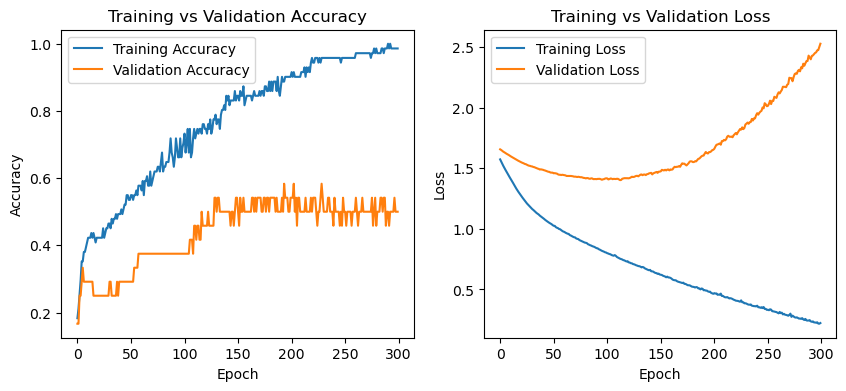

In [125]:
## Your code to plot training and validation curves in a single plot (Make changes in the model cell to be able to do this) :

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
#-- Generate predicted y values

#Note: Keras predict returns the predicted column index location for classification models
X_test_nn = preprocess.transform(X_test)

prediction_probs = keras_model.predict(X_test_nn)

prediction_column_index = np.argmax(prediction_probs, axis=1)

# extract correct prediction labels
prediction_labels = [y_train_nn.columns[i] for i in prediction_column_index]

## Write lines of code to show model performance by comparing prediction_labels with true labels:

print("Accuracy:", accuracy_score(y_test, prediction_labels))

print("\nClassification Report:")
print(classification_report(y_test, prediction_labels))

print("\nConfusion Matrix:")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Accuracy: 0.6190476190476191

Classification Report:
              precision    recall  f1-score   support

     Average       0.60      0.75      0.67         8
        High       0.60      0.38      0.46         8
         Low       0.50      0.50      0.50         8
   Very High       0.70      0.78      0.74         9
    Very Low       0.67      0.67      0.67         9

    accuracy                           0.62        42
   macro avg       0.61      0.61      0.61        42
weighted avg       0.62      0.62      0.61        42


Confusion Matrix:


### Regularization: Dropout and Batch Normalization

Implement regularization techniques such as **Dropout** and **Batch Normalization** to improve generalization and observe the change in performance.

> **Note:** Compare training vs. test (or validation) loss and accuracy before and after adding regularization.

/opt/anaconda3/envs/qmss/lib/python3.13/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.1690 - loss: 2.0927 - val_accuracy: 0.3333 - val_loss: 1.5930
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1408 - loss: 1.9517 - val_accuracy: 0.2500 - val_loss: 1.5909
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2676 - loss: 1.9826 - val_accuracy: 0.3750 - val_loss: 1.5883
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1972 - loss: 1.7558 - val_accuracy: 0.4583 - val_loss: 1.5849
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2676 - loss: 1.5130 - val_accuracy: 0.3333 - val_loss: 1.5818
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3803 - loss: 1.5976 - val_accuracy: 0.2917 - val_loss: 1.5730
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3380 - loss: 1.5345 - val_accuracy: 0.2917 - val_loss: 1.5666
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2676 - loss: 1.6053 - val_accuracy: 0.2500 - val_loss: 

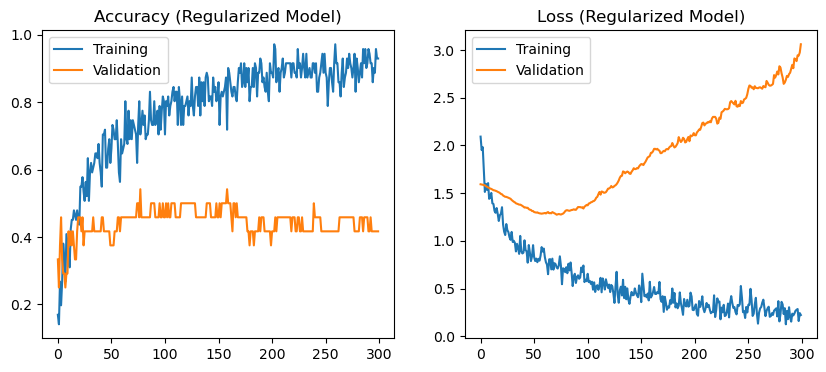

In [ ]:
from keras.layers import Dropout, BatchNormalization

keras_model_reg = Sequential()

keras_model_reg.add(Dense(128, activation='relu', input_shape=(feature_count,)))
keras_model_reg.add(BatchNormalization())
keras_model_reg.add(Dropout(0.3))
keras_model_reg.add(Dense(64, activation='relu'))
keras_model_reg.add(BatchNormalization())
keras_model_reg.add(Dropout(0.3))
keras_model_reg.add(Dense(64, activation='relu'))
keras_model_reg.add(Dropout(0.2))
keras_model_reg.add(Dense(32, activation='relu'))
keras_model_reg.add(Dense(5, activation='softmax'))

keras_model_reg.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

history_reg = keras_model_reg.fit(
    X_train_nn,
    y_train_nn,
    batch_size=20,
    epochs=300,
    validation_split=0.25
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history_reg.history["accuracy"], label="Training")
plt.plot(history_reg.history["val_accuracy"], label="Validation")
plt.title("Accuracy (Regularized Model)")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_reg.history["loss"], label="Training")
plt.plot(history_reg.history["val_loss"], label="Validation")
plt.title("Loss (Regularized Model)")
plt.legend()

plt.show()

Response:

The training curves show that training accuracy steadily increases while validation accuracy plateaus around 0.42–0.45. At the same time, training loss continues decreasing while validation loss begins increasing after roughly 50 epochs. This pattern indicates that the model is overfitting the training data. The model initially learns useful patterns, but after additional epochs it begins memorizing noise in the training set. This suggests that training for 300 epochs was unnecessary, and techniques such as early stopping could help prevent overfitting.*Replace this section with your response.*


### Activation Function Experimentation

Experiment with different activation functions — **ReLU**, **LeakyReLU**, **Tanh**, and **Sigmoid** — and compare their impact on model performance.

#Note: for sake of comparison/time to run each model, I'm going to lessen epochs to 150

In [135]:
#ReLU model (baseline):
keras_model_relu = Sequential([
    keras.layers.Input(shape=(feature_count,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')
])

keras_model_relu.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

history_relu = keras_model_relu.fit(
    X_train_nn,
    y_train_nn,
    batch_size=20,
    epochs=150,
    validation_split=0.25
)

Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.1408 - loss: 1.6337 - val_accuracy: 0.2917 - val_loss: 1.5800
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1549 - loss: 1.6127 - val_accuracy: 0.3750 - val_loss: 1.5733
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2113 - loss: 1.5919 - val_accuracy: 0.3750 - val_loss: 1.5672
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2676 - loss: 1.5757 - val_accuracy: 0.3333 - val_loss: 1.5624
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3380 - loss: 1.5605 - val_accuracy: 0.3333 - val_loss: 1.5572
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3803 - loss: 1.5446 - val_accuracy: 0.3333 - val_loss: 1.5521
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4085 - loss: 1.5305 - val_accuracy: 0.3333 - val_loss: 1.5475
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4225 - loss: 1.5160 - val_accuracy: 0.3333 - val_loss: 

In [137]:
#Leaky ReLU:
from keras.layers import LeakyReLU

keras_model_leaky = Sequential([
    keras.layers.Input(shape=(feature_count,)),
    Dense(128),
    LeakyReLU(alpha=0.01),
    Dense(64),
    LeakyReLU(alpha=0.01),
    Dense(64),
    LeakyReLU(alpha=0.01),
    Dense(32),
    LeakyReLU(alpha=0.01),
    Dense(5, activation='softmax')
])

keras_model_leaky.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

history_leaky = keras_model_leaky.fit(
    X_train_nn,
    y_train_nn,
    batch_size=20,
    epochs=150,
    validation_split=0.25
)

Epoch 1/150


/opt/anaconda3/envs/qmss/lib/python3.13/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.2113 - loss: 1.6328 - val_accuracy: 0.2083 - val_loss: 1.6099
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3380 - loss: 1.6090 - val_accuracy: 0.2500 - val_loss: 1.6057
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3803 - loss: 1.5855 - val_accuracy: 0.2500 - val_loss: 1.6010
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3944 - loss: 1.5650 - val_accuracy: 0.2500 - val_loss: 1.5959
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3944 - loss: 1.5455 - val_accuracy: 0.2500 - val_loss: 1.5911
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3944 - loss: 1.5287 - val_accuracy: 0.2500 - val_loss: 1.5864
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3944 - loss: 1.5093 - val_accuracy: 0.2500 - val_loss: 1.5817
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3944 - loss: 1.4926 - val_accuracy: 0.2500 - val_loss: 1.5777
Epoch 9/15

In [138]:
#Tanh model:

keras_model_tanh = Sequential([
    keras.layers.Input(shape=(feature_count,)),
    Dense(128, activation='tanh'),
    Dense(64, activation='tanh'),
    Dense(64, activation='tanh'),
    Dense(32, activation='tanh'),
    Dense(5, activation='softmax')
])

keras_model_tanh.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

history_tanh = keras_model_tanh.fit(
    X_train_nn,
    y_train_nn,
    batch_size=20,
    epochs=150,
    validation_split=0.25
)

Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.5070 - loss: 1.4466 - val_accuracy: 0.4167 - val_loss: 1.4272
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5070 - loss: 1.2984 - val_accuracy: 0.4583 - val_loss: 1.3763
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5070 - loss: 1.2251 - val_accuracy: 0.4583 - val_loss: 1.3502
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5915 - loss: 1.1775 - val_accuracy: 0.4167 - val_loss: 1.3358
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5775 - loss: 1.1442 - val_accuracy: 0.3750 - val_loss: 1.3292
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5915 - loss: 1.1151 - val_accuracy: 0.3750 - val_loss: 1.3198
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5493 - loss: 1.0964 - val_accuracy: 0.3750 - val_loss: 1.3125
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5493 - loss: 1.0723 - val_accuracy: 0.4167 - val_loss:

In [140]:
#Sigmoid model:
keras_model_sigmoid = Sequential([
    keras.layers.Input(shape=(feature_count,)),
    Dense(128, activation='sigmoid'),
    Dense(64, activation='sigmoid'),
    Dense(64, activation='sigmoid'),
    Dense(32, activation='sigmoid'),
    Dense(5, activation='softmax')
])

keras_model_sigmoid.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

history_sigmoid = keras_model_sigmoid.fit(
    X_train_nn,
    y_train_nn,
    batch_size=20,
    epochs=150,
    validation_split=0.25
)

Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.2676 - loss: 1.6337 - val_accuracy: 0.2083 - val_loss: 1.6410
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1972 - loss: 1.6303 - val_accuracy: 0.2083 - val_loss: 1.6417
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1972 - loss: 1.6246 - val_accuracy: 0.1667 - val_loss: 1.6436
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1549 - loss: 1.6223 - val_accuracy: 0.1667 - val_loss: 1.6417
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1549 - loss: 1.6185 - val_accuracy: 0.1667 - val_loss: 1.6401
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2113 - loss: 1.6169 - val_accuracy: 0.1667 - val_loss: 1.6415
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2113 - loss: 1.6150 - val_accuracy: 0.1667 - val_loss: 1.6407
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2113 - loss: 1.6121 - val_accuracy: 0.1667 - val_loss: 1.6407

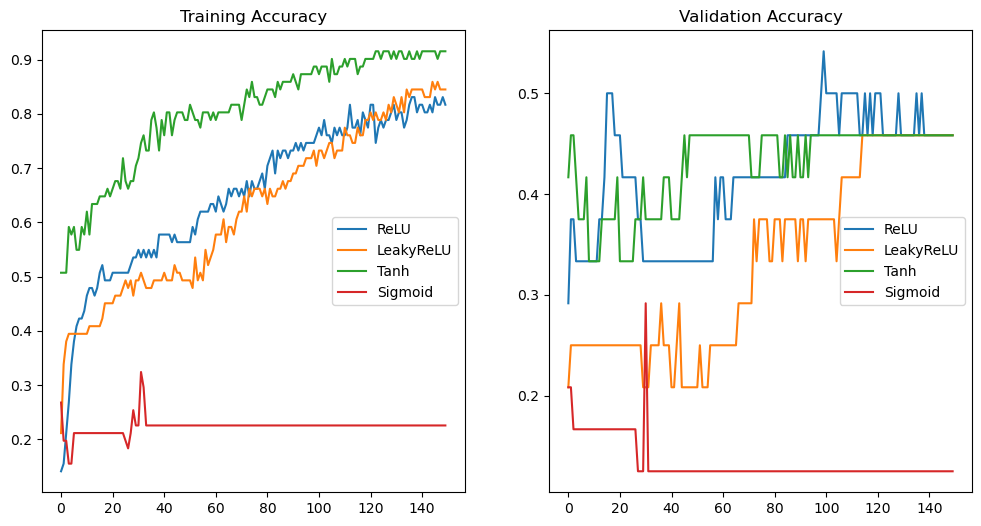

In [145]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.plot(history_relu.history['accuracy'], label='ReLU')
plt.plot(history_leaky.history['accuracy'], label='LeakyReLU')
plt.plot(history_tanh.history['accuracy'], label='Tanh')
plt.plot(history_sigmoid.history['accuracy'], label='Sigmoid')
plt.title("Training Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_relu.history['val_accuracy'], label='ReLU')
plt.plot(history_leaky.history['val_accuracy'], label='LeakyReLU')
plt.plot(history_tanh.history['val_accuracy'], label='Tanh')
plt.plot(history_sigmoid.history['val_accuracy'], label='Sigmoid')
plt.title("Validation Accuracy")
plt.legend()

plt.show()

The activation functions produced different learning behaviors. ReLU achieved the highest validation accuracy (~0.50) and showed stable learning across epochs. LeakyReLU performed similarly but slightly worse. Tanh achieved the highest training accuracy but did not improve validation performance, indicating some overfitting. Sigmoid performed poorly, with both training and validation accuracy remaining low due to the vanishing gradient problem. Overall, ReLU provided the best balance between training performance and generalization.

---

## 8. Explainability – SHAP Feature Importance

To better understand the model's predictions, we will use **SHAP (SHapley Additive exPlanations)** to analyze feature importance.

**How SHAP works:**

- SHAP assigns each feature a contribution score for every prediction.
- It uses Shapley values (from cooperative game theory) to fairly distribute importance across features.

We will apply SHAP to visualize and interpret the model's feature contributions.

/opt/anaconda3/envs/qmss/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/qmss/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/qmss/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/qmss/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/qmss/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/opt/anaconda3/

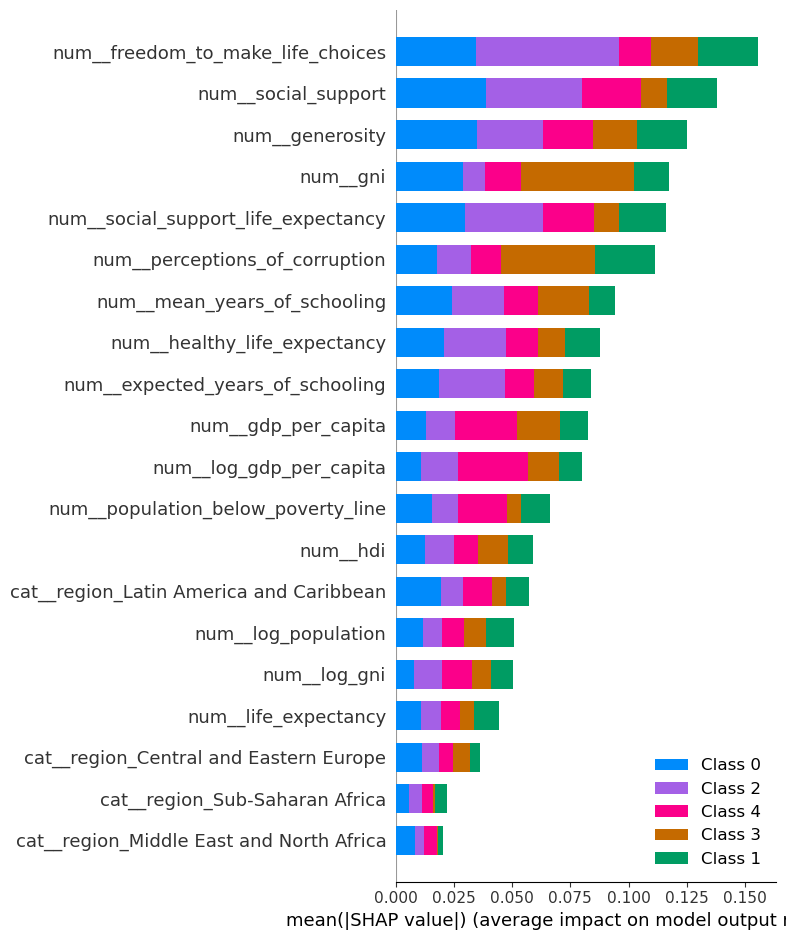

In [148]:
# Import necessary libraries
!pip install shap
import shap
import matplotlib.pyplot as plt
import pandas as pd

# Transform the test data using the fitted preprocessor
X_test_processed = preprocess.transform(X_test)

# Generate feature names after preprocessing
feature_names = preprocess.get_feature_names_out()

# Convert processed test data to a DataFrame for readability
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names)

# Initialize SHAP explainer using the trained model
explainer = shap.Explainer(model.predict_proba, X_test_processed_df)

# Compute SHAP values for X_test
shap_values = explainer(X_test_processed_df)

# Generate SHAP summary plot
shap.summary_plot(shap_values, X_test_processed_df)

# Your cell should output a SHAP summary plot showing the most important features.


### Experimentation

In [ ]:
## You are encouraged to try more experimentation and any other models by adding more code cells to this notebook:

## You can also try to import any new dataset pertaining to countries, merge it, and see if it helps the predictions.
## If it does not, try to explain why it wasn't helpful by exploring variable relationships.

#Reponse:
#Will experiment on my own time as I find this extremely interesting and this code book lays out a great framework for me to experiment with different models and techniques. I will also try to implement early stopping & less epochs in my deep learning model to see if it helps with overfitting.


Deep learning models are often considered "black boxes" due to their complexity. Use SHAP to explain your model's predictions.

After applying SHAP, discuss:

- Does it provide a clear and sufficient explanation of how the model makes decisions?
- How easy or difficult is it to justify your model's predictions using this technique?

In [ ]:
Applying SHAP provides useful insights into how the model makes predictions by quantifying the contribution of each feature to the model's output. The SHAP summary plot ranks features by their importance and shows how strongly they influence classification decisions across different classes. In this case, variables related to social support, education, health, and corruption perceptions appear to have the strongest impact on the predicted happiness categories, which aligns with known drivers of well-being.

However, while SHAP improves interpretability, it does not fully eliminate the "black box" nature of deep learning models. The method explains how individual features contribute to predictions but does not provide a simple global rule for how the neural network processes inputs internally. Additionally, interpreting SHAP outputs for multiclass models can become complex because feature contributions vary across different prediction classes.

Overall, SHAP makes it significantly easier to justify the model’s predictions compared to using the raw neural network alone, but the explanations still require interpretation and do not provide a fully transparent view of the model’s internal decision-making process.

*Replace this section with your response.*

**TODO**

---

## 9. Final Report Submission (GitHub)

This is your final project to showcase on GitHub.

### Instructions

1. Create a new notebook for the final report.
2. Include relevant visualizations.
3. Reproduce the code for the best-performing model(s) and display results.
4. Summarize key insights and observed behaviors.
5. Present the work in a clean, concise report format (within the `.ipynb`).
6. Upload the final notebook to a new repository on your personal GitHub account.
7. Paste the link to your final repository at the top of this notebook where requested.